# P1 · Feed-forward blocks and residual paths

Unit 0 foundations for the current Tiny Transformer and the later Phyll course. Basic Python variables, loops and functions are assumed.

Download and open this notebook in Jupyter, or choose **File → Upload notebook** in Google Colab. All examples and the required helper code are included. No account key, private repository, GPU or dataset download is needed.

Examples are **illustrative**, executed with Python and PyTorch. Newly constructed model weights are explicitly untrained. Run from a fresh kernel in order. Each exercise can run before you fill it in; open its folded solution afterward.

The `show` helper prints named intermediate results. It is course code, not a built-in Python or PyTorch function.

In [1]:
import sys, math
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
torch.set_num_threads(1)
torch.manual_seed(7)
print("Python", sys.version.split()[0], "· PyTorch", torch.__version__, "· CPU")
print("Reference environment: Python 3.12 / PyTorch 2.10. Run with Colab's installed PyTorch or the course requirements.txt.")


Python 3.12.3 · PyTorch 2.10.0+cpu · CPU
Reference environment: Python 3.12 / PyTorch 2.10. Run with Colab's installed PyTorch or the course requirements.txt.


Publication destination: the [public course labs repository](https://github.com/gkiri/tiny_repo). This notebook includes its own examples and can run before that mirror is published.

In [2]:
#@title Display helper: print and draw executed values { display-mode: "form" }
"""Small display helper embedded verbatim in independent notebooks; traces record real executions."""
import json
import math

FRAMES = []


def plain(value):
    if hasattr(value, "detach"):
        return plain(value.detach().cpu().tolist())
    if isinstance(value, dict):
        return {str(k): plain(v) for k, v in value.items()}
    if isinstance(value, (list, tuple)):
        return [plain(v) for v in value]
    if isinstance(value, float) and not math.isfinite(value):
        return str(value)
    if value is None or isinstance(value, (str, int, float, bool)):
        return value
    return str(value)


def show(label, value):
    """Print and snapshot an intermediate. This helper is course code, not a PyTorch API."""
    frame = {"label": label, "value": plain(value)}
    if hasattr(value, "shape"):
        frame.update(shape=list(value.shape), dtype=str(value.dtype), device=str(value.device))
    FRAMES.append(frame)
    print(label + ":", json.dumps(frame["value"], ensure_ascii=False))
    if "shape" in frame:
        print("  shape", frame["shape"], "·", frame["dtype"], "·", frame["device"])


def draw_trace():
    """A portable SVG trace diagram; requires only the notebook's existing IPython display."""
    import html
    from IPython.display import SVG, display
    height = 82 * len(FRAMES) + 12
    parts = [f'<svg xmlns="http://www.w3.org/2000/svg" viewBox="0 0 720 {height}" role="img" aria-label="Executed intermediate values">']
    for i, frame in enumerate(FRAMES):
        y = 8 + 82*i
        value = json.dumps(frame["value"], ensure_ascii=False)
        if len(value) > 91:
            value = value[:88] + "…"
        parts += [f'<rect x="4" y="{y}" width="708" height="68" rx="10" fill="#f4f8ef" stroke="#779861"/>',
                  f'<text x="20" y="{y+25}" font-size="15" font-family="sans-serif" fill="#31524b">{i+1}. {html.escape(frame["label"])}</text>',
                  f'<text x="20" y="{y+48}" font-size="12" font-family="monospace" fill="#252a33">{html.escape(value)}</text>']
        if i + 1 < len(FRAMES):
            parts.append(f'<path d="M360 {y+68} v14" stroke="#7042a6" stroke-width="2"/>')
    display(SVG("".join(parts) + "</svg>"))

## P1.12 · Feed-forward blocks and residual paths

A branch can widen its hidden features, then return to the original width so a residual addition is valid.

**Prerequisites:** Assemble attention tensors

**Predict:** What width must the branch return for an intended residual add?

**Mental model:** Attention mixes information across allowed positions. A feed-forward branch instead transforms each token vector with the same learned feature transformation.

### P1.12.1 · Understand the need

Attention mixes information across allowed positions. A feed-forward branch instead transforms each token vector with the same learned feature transformation.

Its hidden layer can use a wider feature space. A nonlinear activation between two linear layers lets the branch express more than a single affine transformation.

LayerNorm prepares each token vector using the configured feature axes. Its learned scale and shift are part of the module's state.

The branch then returns to the original feature width. Only then can its update be added to the residual input with the intended matching coordinates.

Track shape preservation separately from value preservation. The residual sum keeps the shape while changing the values.

### P1.12.2 · Follow the values

The input contains one example, two token positions and four features per token. Keep this original tensor visible as the residual path.

LayerNorm operates on all four features of each token separately. The two tokens do not share a combined normalization average.

The first linear layer widens each token to six features, then GELU transforms each hidden entry. The experiment can substitute ReLU to show a different activation.

The second linear layer narrows the hidden representation back to four features. Its output is an update with the same shape as the original input.

Add that update to the retained input. A zero branch update would preserve the original values exactly, while a nonzero update changes them at matching coordinates.

In [3]:
FRAMES.clear()
change = 0
torch.manual_seed(7)
x = torch.tensor([[[2.,0.,1.,-1.],[1.,3.,0.,-2.]]])
show("Residual input [1,2,4]", x)
norm = nn.LayerNorm(4)
z = norm(x)
show("Normalize each token's features", z)
wide = nn.Linear(4, 6)
narrow = nn.Linear(6, 4)
hidden = wide(z)
activated = F.relu(hidden) if change else F.gelu(hidden)
show("Hidden activation [1,2,6]", activated)
update = narrow(activated)
show("Branch update [1,2,4]", update)
show("Residual sum [1,2,4]", x + update)

Residual input [1,2,4]: [[[2.0, 0.0, 1.0, -1.0], [1.0, 3.0, 0.0, -2.0]]]
  shape [1, 2, 4] · torch.float32 · cpu
Normalize each token's features: [[[1.3416354656219482, -0.4472118318080902, 0.4472118318080902, -1.3416354656219482], [0.27734971046447754, 1.3867484331130981, -0.27734965085983276, -1.3867484331130981]]]
  shape [1, 2, 4] · torch.float32 · cpu
Hidden activation [1,2,6]: [[[0.0331890806555748, -0.15873833000659943, 0.07312125712633133, 0.07667873799800873, 1.3865294456481934, 0.00981864519417286], [-0.1675417721271515, -0.07838475704193115, 0.49232223629951477, -0.05725349485874176, 0.08264239877462387, -0.1699526160955429]]]
  shape [1, 2, 6] · torch.float32 · cpu
Branch update [1,2,4]: [[[-0.043740153312683105, 0.287968248128891, -0.3206905722618103, 0.6253442764282227], [-0.38187918066978455, 0.05840145796537399, 0.003314986824989319, -0.1488032191991806]]]
  shape [1, 2, 4] · torch.float32 · cpu
Residual sum [1,2,4]: [[[1.956259846687317, 0.287968248128891, 0.6793094277

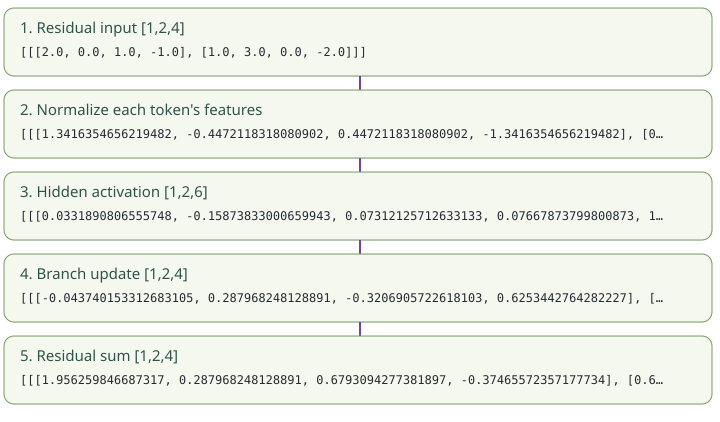

In [4]:
draw_trace()

### See the calculation

The plot uses the tensors just calculated above. Values are rounded for display.

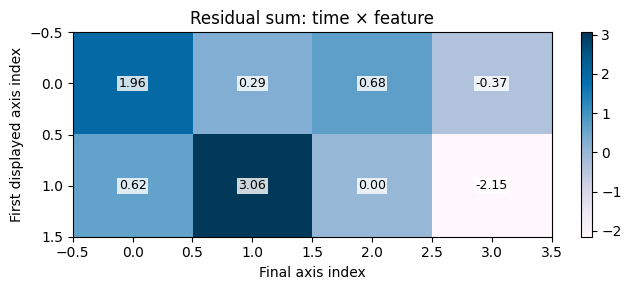

In [5]:
image = ((x+update)[0]).detach().cpu().numpy()
fig, ax = plt.subplots(figsize=(7,3))
plot = ax.imshow(image, cmap="PuBu", aspect="auto")
for row in range(image.shape[0]):
    for col in range(image.shape[1]):
        ax.text(col,row,f"{image[row,col]:.2f}",ha="center",va="center",color="black",fontsize=9,
                bbox={"facecolor":"white","alpha":.8,"edgecolor":"none","pad":1})
ax.set_title('Residual sum: time × feature'); ax.set_xlabel("Final axis index"); ax.set_ylabel("First displayed axis index")
fig.colorbar(plot,ax=ax); plt.tight_layout(); plt.show()

### P1.12.3 · Read and run the code

Construct LayerNorm with the feature width to normalize. Passing a different tuple of normalized axes changes which entries contribute to each statistic.

Linear operates on the final axis while preserving the leading batch and time axes. The same parameters are applied to every token position.

Functional GELU and ReLU act element by element. GELU is deterministic; it is not a random dropout gate.

The residual expression adds the original tensor to the branch result. Check matching intended shapes instead of relying on accidental broadcasting.

Sequential can package the two linear layers and activation. Keeping the intermediate variables here makes their individual shapes inspectable.

### Change one thing

**Compare GELU with ReLU**. Predict which outputs change before running this second case. It executes the same code with `change = 1`.

In [6]:
FRAMES.clear()
change = 1
torch.manual_seed(7)
x = torch.tensor([[[2.,0.,1.,-1.],[1.,3.,0.,-2.]]])
show("Residual input [1,2,4]", x)
norm = nn.LayerNorm(4)
z = norm(x)
show("Normalize each token's features", z)
wide = nn.Linear(4, 6)
narrow = nn.Linear(6, 4)
hidden = wide(z)
activated = F.relu(hidden) if change else F.gelu(hidden)
show("Hidden activation [1,2,6]", activated)
update = narrow(activated)
show("Branch update [1,2,4]", update)
show("Residual sum [1,2,4]", x + update)

Residual input [1,2,4]: [[[2.0, 0.0, 1.0, -1.0], [1.0, 3.0, 0.0, -2.0]]]
  shape [1, 2, 4] · torch.float32 · cpu
Normalize each token's features: [[[1.3416354656219482, -0.4472118318080902, 0.4472118318080902, -1.3416354656219482], [0.27734971046447754, 1.3867484331130981, -0.27734965085983276, -1.3867484331130981]]]
  shape [1, 2, 4] · torch.float32 · cpu
Hidden activation [1,2,6]: [[[0.06319394707679749, 0.0, 0.1323145031929016, 0.13817280530929565, 1.4882413148880005, 0.019338905811309814], [0.0, 0.0, 0.6603927612304688, 0.0, 0.1478959321975708, 0.0]]]
  shape [1, 2, 6] · torch.float32 · cpu
Branch update [1,2,4]: [[[0.020684093236923218, 0.24581244587898254, -0.25400418043136597, 0.6117016077041626], [-0.22485506534576416, -0.027631843462586403, 0.0463280975818634, -0.16150955855846405]]]
  shape [1, 2, 4] · torch.float32 · cpu
Residual sum [1,2,4]: [[[2.020684003829956, 0.24581244587898254, 0.745995819568634, -0.3882983922958374], [0.7751449346542358, 2.9723682403564453, 0.0463280

### A useful distinction

The feed-forward branch changes features per token; its linear layers do not directly mix time positions.

### ✋ Your turn

Add a zero update to x=[2,0,1] and put the resulting list in answer.

In [7]:
answer = None  # TODO: replace with your calculation

if answer is None:
    print("Your turn: fill in `answer` above, then run this cell again.")
else:
    assert answer == [2,0,1], 'The feed-forward branch changes features per token; its linear layers do not directly mix time positions.'
    print("✓ right:", answer)

Your turn: fill in `answer` above, then run this cell again.


In [8]:
#@title Show a solution { display-mode: "form" }
x = torch.tensor([2.,0.,1.])
answer = (x + torch.zeros_like(x)).tolist()

if answer is None:
    print("Your turn: fill in `answer` above, then run this cell again.")
else:
    assert answer == [2,0,1], 'The feed-forward branch changes features per token; its linear layers do not directly mix time positions.'
    print("✓ right:", answer)

✓ right: [2.0, 0.0, 1.0]


### P1.12.4 · Find it in the model

The current transformer's branch widens twenty-eight features to fifty-six, applies GELU, and narrows back to twenty-eight. Its block uses normalization before each branch.

Phyll uses different widths and ReLU, plus dropout in its architecture. These differences must remain explicit when reading the larger model.

Dropout behaves differently in training and evaluation modes. LayerNorm continues to use the input's feature statistics in both modes.

This chapter establishes the API and shape contracts. The maths collection explains normalization, nonlinearity and residual addition in more numerical depth.

Next, interpret the final readout's scores and the targets used to measure their error.

```python
self.ff = nn.Sequential(nn.Linear(cfg.d_model, cfg.d_ff), nn.GELU(), nn.Linear(cfg.d_ff, cfg.d_model))
x = x + self.ff(self.ln2(x))
```

The excerpt illustrates the corresponding operation. Run the complete chapter example above; excerpts can depend on model context.

**Recall:** What width must the branch return for an intended residual add?

<details><summary>Check your explanation</summary>

The residual feature width. The feed-forward branch changes features per token; its linear layers do not directly mix time positions.

</details>